# Cue-centered lag-CRP

Recall probability as a function of study-position lag from the preceding film cue. Unlike the standard lag-CRP (which measures lags between successive recalls), the cue-centered CRP measures lags from the cue to the recall it elicits.

The lag=0 peak reflects cue effectiveness (how often the cue triggers recall of the exact matching clip). Non-zero lags show the error distribution — when a cue doesn't produce an exact match, does the recalled clip tend to be near the cue's position in the film sequence?

The previous version of this notebook consumed a pre-computed `cue_clips` field from the HDF5 that was generated using unreliable embedding-based semantic matching and a cue-attribution rule that did not account for foils breaking cue-recall links. This version derives `cue_clips` from the interleaved event stream (`recall_items`/`recall_types`) using `derive_cue_clips()`, which uses human-coded clip labels and properly clears the pending cue when a foil (type=3) or unclassified utterance (type=4) intervenes.

In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.analyses.cue_centered_crp import plot_cue_centered_crp
from jaxcmr.helpers import find_project_root, load_data
from jaxcmr.selective_interference.analysis import derive_cue_clips

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_CUE_CENTERED_CRP"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = run_tag
max_lag = 4
exclude_zero_lag = False
ylim = None
size = 3

## Deriving cue attributions from the event stream

The interleaved event sequence (`recall_items` + `recall_types`) preserves the full temporal structure of the test phase: cue presentations (type=1), recall events (type=2), foil images (type=3), and unclassified utterances (type=4). `derive_cue_clips()` walks this sequence per trial, tracking the pending cue and clearing it when a foil or unclassified event intervenes, to produce a `cue_clips` array aligned to the unique-first `recalls` array.

We inject the derived `cue_clips` into the data dict so that `plot_cue_centered_crp()` can read it. The `should_tabulate` mask is set to all-True because the cue-centered CRP tabulation already skips events with no cue internally.

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

recalls = np.array(data["recalls"])
cue_clips = derive_cue_clips(
    np.array(data["recall_items"]),
    np.array(data["recall_types"]),
    recalls,
)
data["cue_clips"] = jnp.array(cue_clips)

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]

should_tab = jnp.ones_like(data["recalls"], dtype=bool)

n_cued = int((cue_clips > 0).sum())
n_recalls = int((recalls > 0).sum())
print(f"Loaded {recalls.shape[0]} trials")
print(f"Cued recall events: {n_cued}/{n_recalls} ({n_cued/n_recalls:.1%})")


def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def plot_contrast(masks, labels, contrast_name, axis=None, suffix=None):
    plot_cue_centered_crp(
        datasets=[data] * len(masks),
        trial_masks=masks,
        should_tabulate=[should_tab] * len(masks),
        max_lag=max_lag,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
        exclude_zero_lag=exclude_zero_lag,
        size=size,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()

Loaded 240 trials
Cued recall events: 1120/2017 (55.5%)


## Task (involuntary vs voluntary)

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


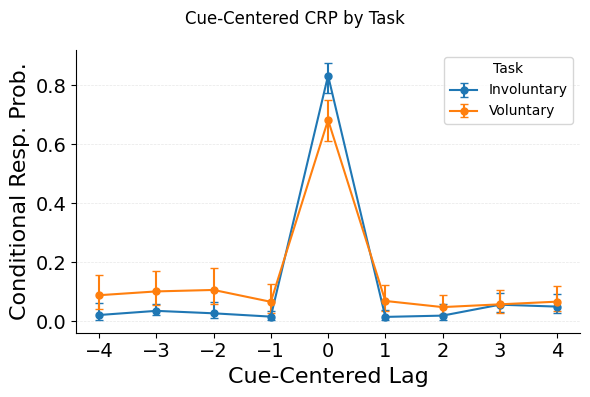

In [4]:
labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, contrast_name="Task", axis=ax)
fig.suptitle("Cue-Centered CRP by Task")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task")

## Condition (emotional vs neutral)

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


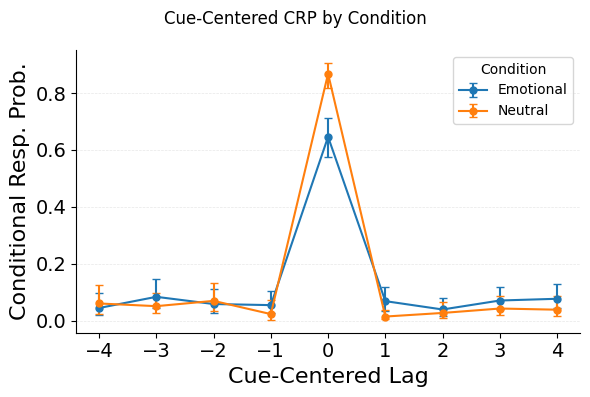

In [5]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, contrast_name="Condition", axis=ax)
fig.suptitle("Cue-Centered CRP by Condition")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition")

## Intervention (podcast vs Tetris)

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


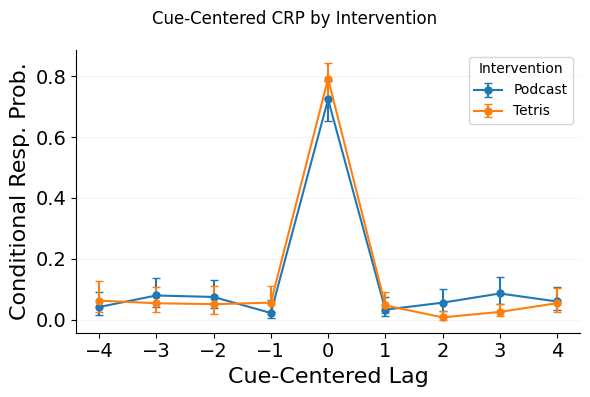

In [6]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)
fig.suptitle("Cue-Centered CRP by Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention")

## Task x Condition

Invol+Emotional: trials=60, subjects=60
Invol+Neutral: trials=60, subjects=60


Vol+Emotional: trials=60, subjects=60
Vol+Neutral: trials=60, subjects=60


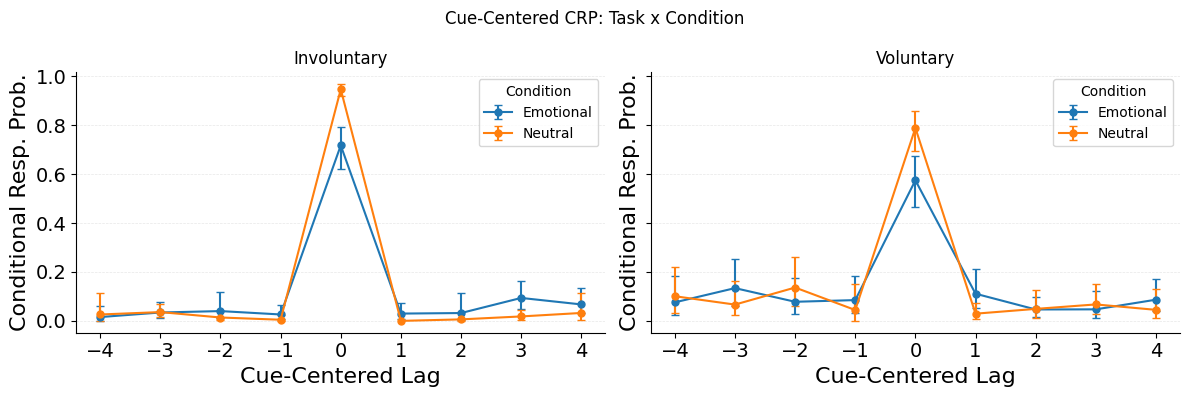

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Involuntary by condition
labels = ["Emotional", "Neutral"]
masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 1) & (condition == 2)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Condition", axis=axes[0])
axes[0].set_title("Involuntary")

# Voluntary by condition
masks = [
    trial_mask((task == 2) & (condition == 1)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Condition", axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Cue-Centered CRP: Task x Condition")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition")

## Task x Intervention

Invol+Podcast: trials=60, subjects=60
Invol+Tetris: trials=60, subjects=60


Vol+Podcast: trials=60, subjects=60
Vol+Tetris: trials=60, subjects=60


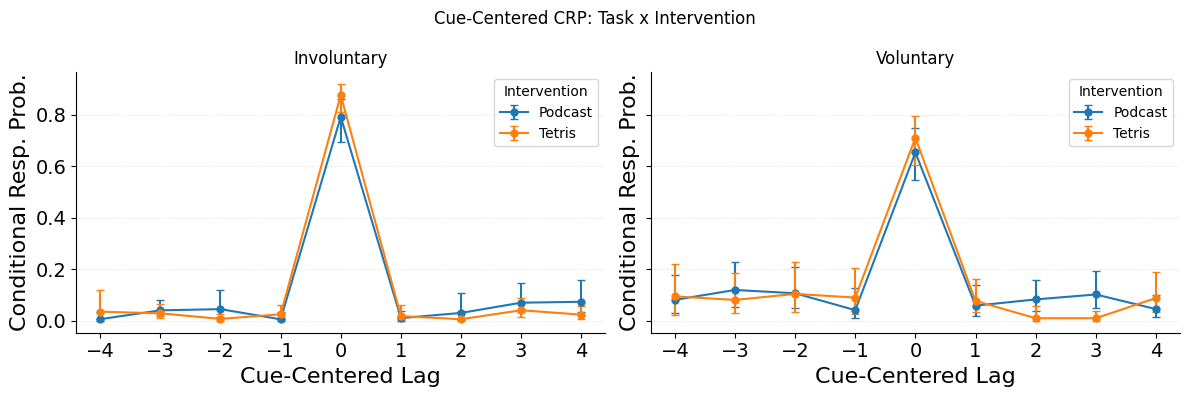

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Involuntary by intervention
labels = ["Podcast", "Tetris"]
masks = [
    trial_mask((task == 1) & (intervention == 0)),
    trial_mask((task == 1) & (intervention == 1)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[0])
axes[0].set_title("Involuntary")

# Voluntary by intervention
masks = [
    trial_mask((task == 2) & (intervention == 0)),
    trial_mask((task == 2) & (intervention == 1)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Cue-Centered CRP: Task x Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention")

## Condition x Intervention

Emot+Podcast: trials=60, subjects=60
Emot+Tetris: trials=60, subjects=60


Neut+Podcast: trials=60, subjects=60
Neut+Tetris: trials=60, subjects=60


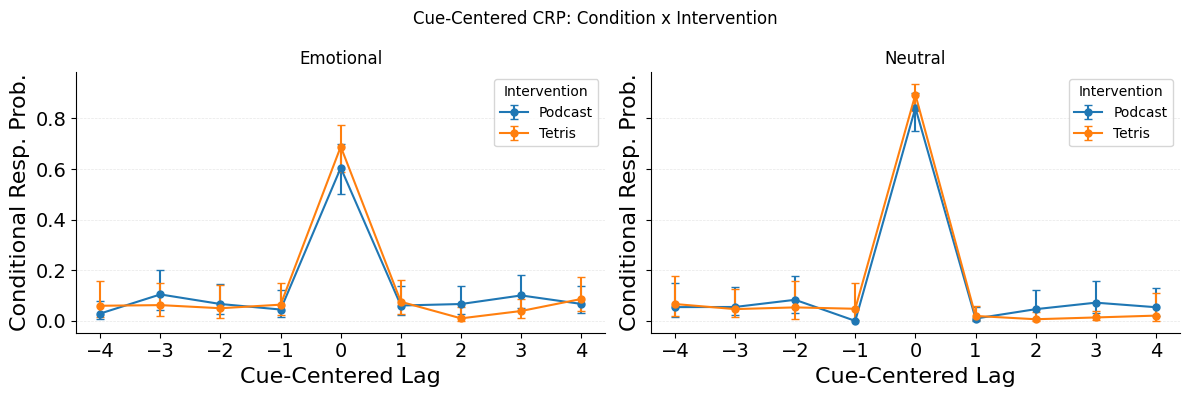

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Emotional by intervention
labels = ["Podcast", "Tetris"]
masks = [
    trial_mask((condition == 1) & (intervention == 0)),
    trial_mask((condition == 1) & (intervention == 1)),
]
summarize_masks([f"Emot+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[0])
axes[0].set_title("Emotional")

# Neutral by intervention
masks = [
    trial_mask((condition == 2) & (intervention == 0)),
    trial_mask((condition == 2) & (intervention == 1)),
]
summarize_masks([f"Neut+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle("Cue-Centered CRP: Condition x Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_intervention")